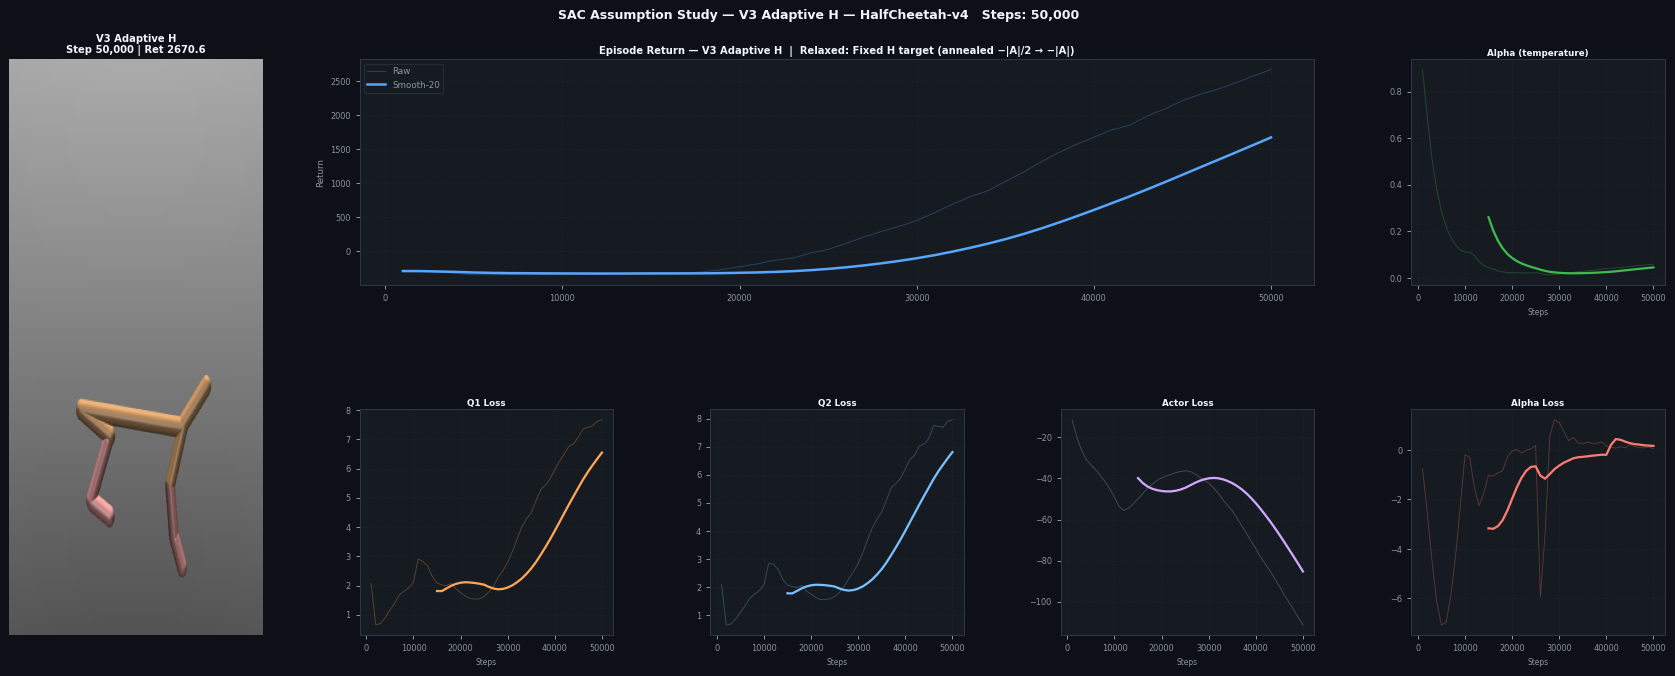

      50,000     2670.6    7.6712 -111.3910   0.0590  15 SPS

✓ V3 Adaptive H done in 54.6 min


  All variants complete — rendering comparison dashboard



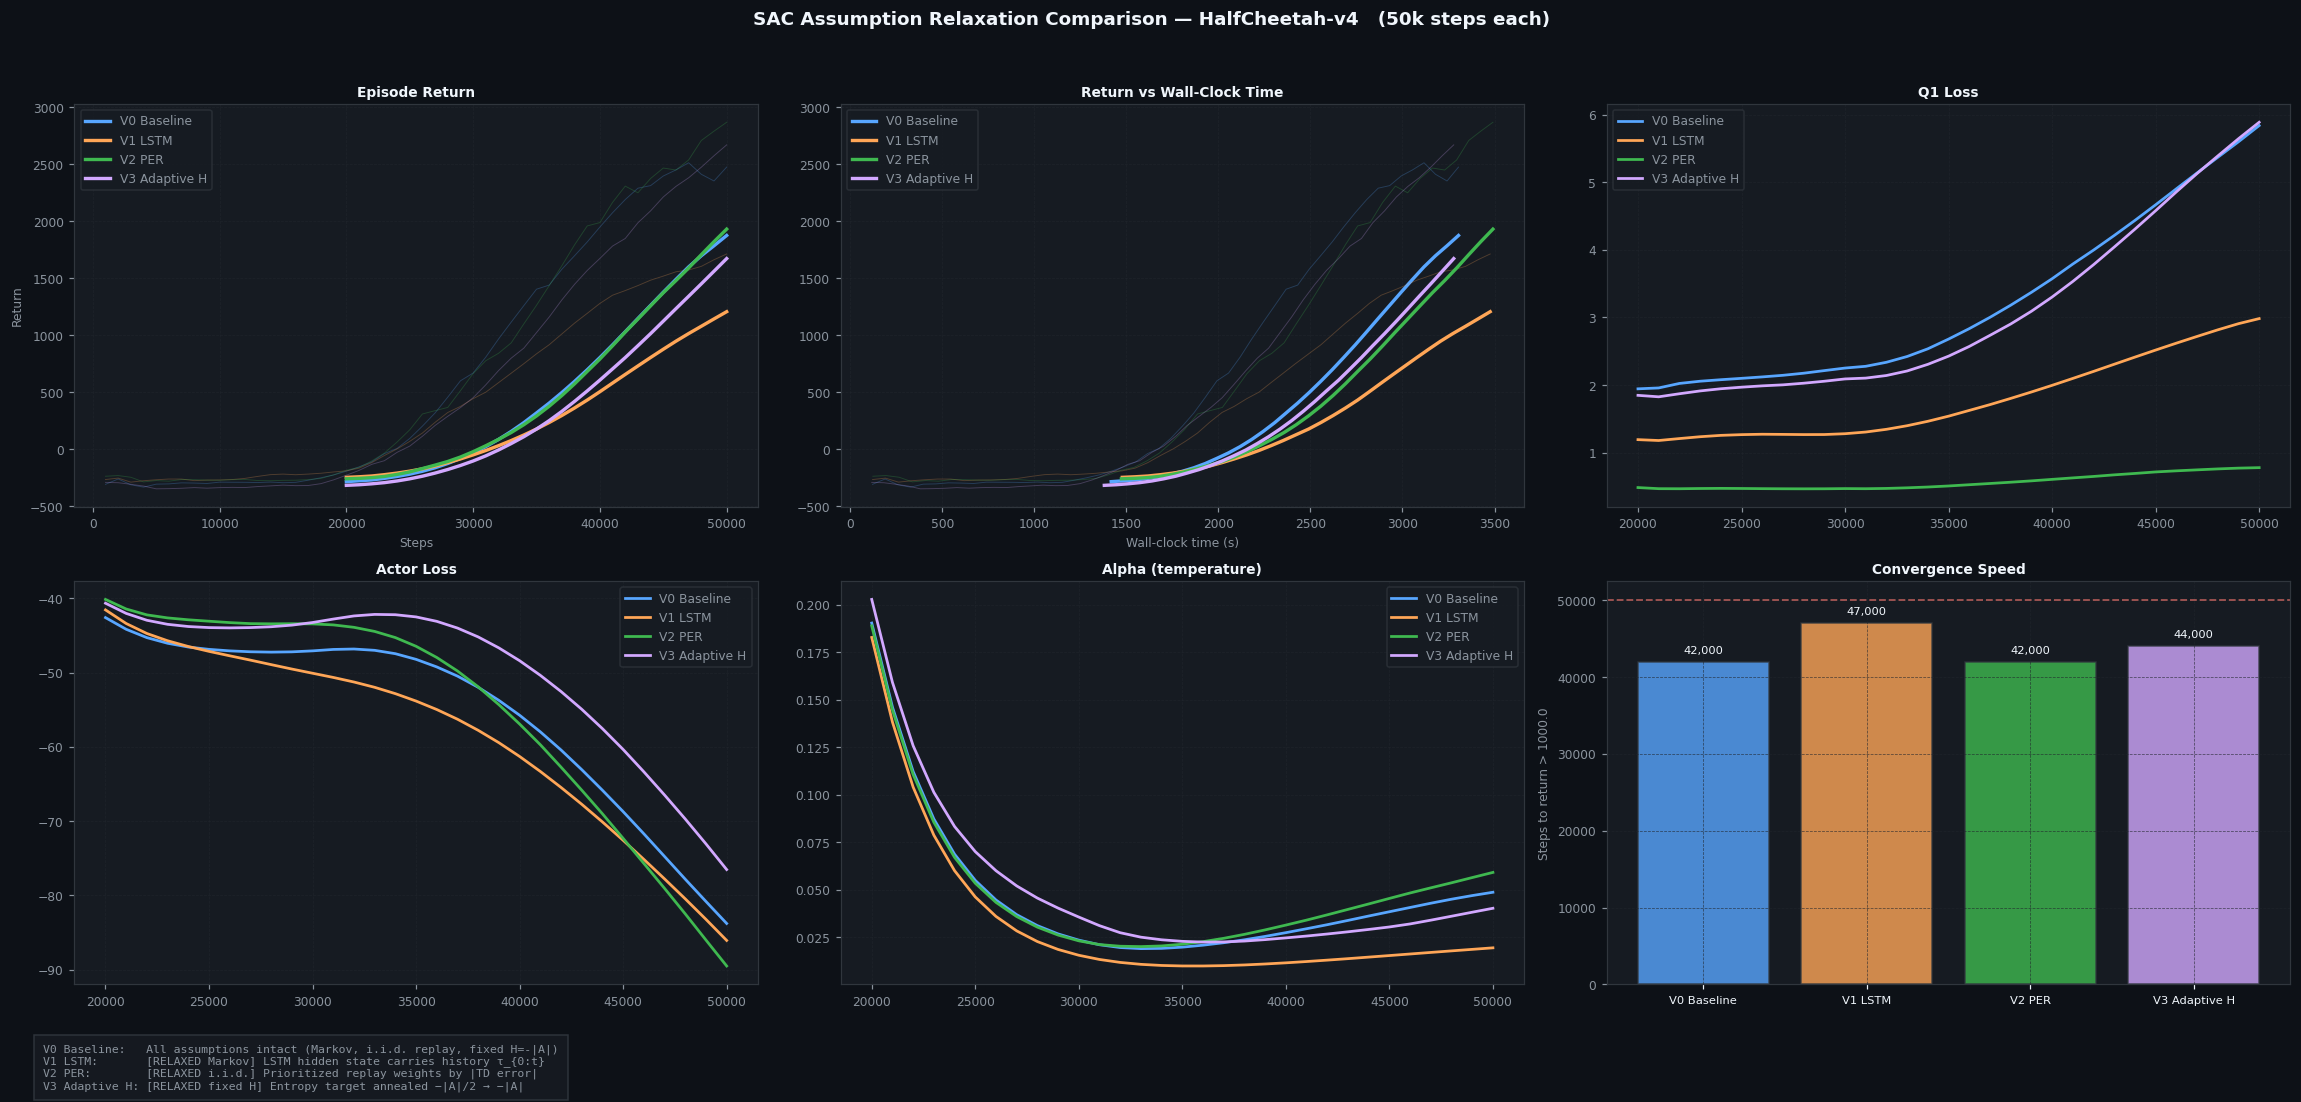


Comparison figure saved → /kaggle/working/sac_assumption_comparison.png

── Training time summary ──────────────────────────────
Variant                  Total time (min)
──────────────────────────────────────────
V0 Baseline                         55.1
V1 LSTM                             57.9
V2 PER                              58.2
V3 Adaptive H                       54.6


In [2]:
#  SAC — Assumption Relaxation Study — HalfCheetah-v4
#  Kaggle single-cell notebook.
#
#  Runs 4 variants sequentially, each for 1M steps:
#
#  V0  Baseline SAC          (all original assumptions intact)
#  V1  + LSTM policy/critic  (relaxes Markov assumption)
#  V2  + PER                 (relaxes i.i.d. replay assumption)
#  V3  + Adaptive H target   (relaxes fixed entropy target assumption)


import os
os.environ["MUJOCO_GL"]         = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"
os.environ["LD_PRELOAD"]        = ""

import subprocess, sys

IN_KAGGLE = os.path.exists('/kaggle/working')
if IN_KAGGLE:
    subprocess.run(["apt-get", "install", "-y", "-q",
                    "libgl1-mesa-glx", "libosmesa6", "libosmesa6-dev",
                    "libglfw3"], capture_output=True)
    print("✓ System GL libraries ready")

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)

for pkg in ["gymnasium", "gymnasium[mujoco]", "torch",
            "numpy", "matplotlib", "pillow", "imageio"]:
    pip(pkg)
print("✓ Python dependencies ready")

import time, random, io, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions import Normal

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque, namedtuple

from IPython.display import display, clear_output
from PIL import Image

# Environment
try:
    import gymnasium as gym
    _e = gym.make("HalfCheetah-v4", render_mode="rgb_array")
    _e.reset(); _e.close()
    ENV_ID = "HalfCheetah-v4"
    print("✓ MuJoCo found — using HalfCheetah-v4")
except Exception:
    import gymnasium as gym
    ENV_ID = "CartPole-v1"
    print("ℹ MuJoCo not available — falling back to CartPole-v1")

# Shared hyperparameters
SEED             = 123456
TOTAL_TIMESTEPS  = 50_000 # Shorter Training for Comparisons
HIDDEN_SIZE      = 256
BATCH_SIZE       = 256
REPLAY_SIZE      = 50_000
START_STEPS      = 10_000
UPDATES_PER_STEP = 1
GAMMA            = 0.99      # [ASSUMPTION: geometric discount — kept in all variants]
TAU              = 0.005
LR               = 3e-4
ALPHA_INIT       = 0.2
TARGET_UPDATE_INTERVAL = 1
PLOT_EVERY       = 1_000
RENDER_EVERY     = 1_000

LOG_SIG_MAX =  2
LOG_SIG_MIN = -20
EPSILON     = 1e-6

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


#  SHARED UTILITIES

def soft_update(target, source, tau):
    for t, s in zip(target.parameters(), source.parameters()):
        t.data.copy_(t.data * (1.0 - tau) + s.data * tau)

def hard_update(target, source):
    for t, s in zip(target.parameters(), source.parameters()):
        t.data.copy_(s.data)

def weights_init_(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=1)
        nn.init.constant_(m.bias, 0)


#  V0 / V2 / V3  —  MLP NETWORKS  (pranz24 verbatim)
#  [ASSUMPTION: Markov — policy conditioned on s_t only, no history]

class QNetwork(nn.Module):
    # Twin Q-networks. [ASSUMPTION: Markov — Q(s,a) sufficient]
    def __init__(self, num_inputs, num_actions, hidden_dim):
        super().__init__()
        self.l1 = nn.Linear(num_inputs + num_actions, hidden_dim)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.l3 = nn.Linear(hidden_dim, 1)
        self.l4 = nn.Linear(num_inputs + num_actions, hidden_dim)
        self.l5 = nn.Linear(hidden_dim, hidden_dim)
        self.l6 = nn.Linear(hidden_dim, 1)
        self.apply(weights_init_)

    def forward(self, state, action):
        xu = torch.cat([state, action], 1)
        x1 = F.relu(self.l1(xu)); x1 = F.relu(self.l2(x1)); x1 = self.l3(x1)
        x2 = F.relu(self.l4(xu)); x2 = F.relu(self.l5(x2)); x2 = self.l6(x2)
        return x1, x2


class GaussianPolicy(nn.Module):
    """
    Squashed Gaussian MLP policy.
    [ASSUMPTION: Markov — π(a|s_t), no recurrent state]
    [ASSUMPTION: diagonal Gaussian — no action correlations]
    """
    def __init__(self, num_inputs, num_actions, hidden_dim, action_space=None):
        super().__init__()
        self.l1 = nn.Linear(num_inputs, hidden_dim)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.mean_l    = nn.Linear(hidden_dim, num_actions)
        self.log_std_l = nn.Linear(hidden_dim, num_actions)
        self.apply(weights_init_)
        if action_space is None:
            self.action_scale = torch.tensor(1.)
            self.action_bias  = torch.tensor(0.)
        else:
            self.action_scale = torch.FloatTensor(
                (action_space.high - action_space.low) / 2.)
            self.action_bias  = torch.FloatTensor(
                (action_space.high + action_space.low) / 2.)

    def forward(self, state):
        x = F.relu(self.l1(state)); x = F.relu(self.l2(x))
        mean    = self.mean_l(x)
        log_std = torch.clamp(self.log_std_l(x), LOG_SIG_MIN, LOG_SIG_MAX)
        return mean, log_std

    def sample(self, state):
        mean, log_std = self.forward(state)
        std  = log_std.exp()
        dist = Normal(mean, std)
        x_t  = dist.rsample()
        y_t  = torch.tanh(x_t)
        action = y_t * self.action_scale.to(state.device) \
                     + self.action_bias.to(state.device)
        log_prob = dist.log_prob(x_t)
        log_prob -= torch.log(
            self.action_scale.to(state.device) * (1 - y_t.pow(2)) + EPSILON)
        log_prob = log_prob.sum(1, keepdim=True)
        mean_out = torch.tanh(mean) * self.action_scale.to(state.device) \
                                    + self.action_bias.to(state.device)
        return action, log_prob, mean_out

    def to(self, device):
        self.action_scale = self.action_scale.to(device)
        self.action_bias  = self.action_bias.to(device)
        return super().to(device)


#  V1  —  LSTM NETWORKS
#  [RELAXED: Markov assumption — policy now conditions on a
#   hidden state h_t that summarises history τ_{0:t}]
#
#  Design note: we use a 1-layer LSTM with hidden_dim units.
#  The critic receives the LSTM embedding of the state sequence
#  (not raw s_t) so value estimation also benefits from history.
#  The hidden state is reset at episode boundaries.

class LSTMQNetwork(nn.Module):
    """
    [RELAXED: Markov] Q(τ_{0:t}, a_t) via LSTM encoder.
    Input s_t is encoded through an LSTM before the Q-head.
    During off-policy training we feed single-step sequences
    (seq_len=1) — a pragmatic compromise that gives the network
    the *capacity* for history without requiring full-sequence
    replay (which would need episode-structured buffers).
    """
    def __init__(self, num_inputs, num_actions, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(num_inputs, hidden_dim, batch_first=True)
        # Q1
        self.l1 = nn.Linear(hidden_dim + num_actions, hidden_dim)
        self.l2 = nn.Linear(hidden_dim, 1)
        # Q2
        self.l3 = nn.Linear(hidden_dim + num_actions, hidden_dim)
        self.l4 = nn.Linear(hidden_dim, 1)

    def forward(self, state, action, hidden=None):
        # state: (B, obs_dim) → unsqueeze to (B, 1, obs_dim) for LSTM
        x, hidden_out = self.lstm(state.unsqueeze(1), hidden)
        x = x.squeeze(1)   # (B, hidden_dim)
        xu1 = F.relu(self.l1(torch.cat([x, action], 1)))
        xu2 = F.relu(self.l3(torch.cat([x, action], 1)))
        return self.l2(xu1), self.l4(xu2), hidden_out


class LSTMGaussianPolicy(nn.Module):
    """
    [RELAXED: Markov] π(a_t | τ_{0:t}) via LSTM.
    Same squashed-Gaussian output as MLP version.
    """
    def __init__(self, num_inputs, num_actions, hidden_dim, action_space=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm       = nn.LSTM(num_inputs, hidden_dim, batch_first=True)
        self.mean_l    = nn.Linear(hidden_dim, num_actions)
        self.log_std_l = nn.Linear(hidden_dim, num_actions)
        if action_space is None:
            self.action_scale = torch.tensor(1.)
            self.action_bias  = torch.tensor(0.)
        else:
            self.action_scale = torch.FloatTensor(
                (action_space.high - action_space.low) / 2.)
            self.action_bias  = torch.FloatTensor(
                (action_space.high + action_space.low) / 2.)

    def forward(self, state, hidden=None):
        x, hidden_out = self.lstm(state.unsqueeze(1), hidden)
        x = x.squeeze(1)
        mean    = self.mean_l(x)
        log_std = torch.clamp(self.log_std_l(x), LOG_SIG_MIN, LOG_SIG_MAX)
        return mean, log_std, hidden_out

    def sample(self, state, hidden=None):
        mean, log_std, hidden_out = self.forward(state, hidden)
        std  = log_std.exp()
        dist = Normal(mean, std)
        x_t  = dist.rsample()
        y_t  = torch.tanh(x_t)
        action = y_t * self.action_scale.to(state.device) \
                     + self.action_bias.to(state.device)
        log_prob = dist.log_prob(x_t)
        log_prob -= torch.log(
            self.action_scale.to(state.device) * (1 - y_t.pow(2)) + EPSILON)
        log_prob = log_prob.sum(1, keepdim=True)
        mean_out = torch.tanh(mean) * self.action_scale.to(state.device) \
                                    + self.action_bias.to(state.device)
        return action, log_prob, mean_out, hidden_out

    def to(self, device):
        self.action_scale = self.action_scale.to(device)
        self.action_bias  = self.action_bias.to(device)
        return super().to(device)


#  REPLAY MEMORIES

class ReplayMemory:
    """
    Uniform random replay.
    [ASSUMPTION: i.i.d. sampling — all transitions equally likely]
    Used by V0, V1, V3.
    """
    def __init__(self, capacity, seed):
        random.seed(seed)
        self.capacity = capacity
        self.buffer   = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = map(np.stack, zip(*batch))
        return s, a, r, ns, d

    def __len__(self):
        return len(self.buffer)


class PrioritizedReplayMemory:
    """
    Prioritized Experience Replay (Schaul et al., 2016).
    [RELAXED: i.i.d. assumption — transitions sampled proportional
     to their TD-error, giving more weight to surprising transitions]

    Priority p_i = |δ_i| + ε_per
    P(i) ∝ p_i^α_per
    Importance-sampling weights w_i = (N · P(i))^{-β} / max_j w_j
    β is annealed from β_start → 1 over training to correct bias.

    Implementation uses a sum-tree for O(log N) sampling.
    """
    def __init__(self, capacity, seed,
                 alpha_per=0.6, beta_start=0.4, beta_steps=None):
        random.seed(seed)
        self.capacity   = capacity
        self.alpha      = alpha_per
        self.beta_start = beta_start
        self.beta_steps = beta_steps or TOTAL_TIMESTEPS
        self.eps        = 1e-6

        # Sum-tree: tree[i] stores priority sum for subtree rooted at i
        self.tree_size  = 1
        while self.tree_size < capacity:
            self.tree_size *= 2
        self.tree    = np.zeros(2 * self.tree_size)
        self.data    = [None] * self.tree_size
        self.n_items = 0
        self.write   = 0
        self.step    = 0
        self.max_priority = 1.0

    def _update_tree(self, idx, priority):
        pos = idx + self.tree_size
        self.tree[pos] = priority
        pos //= 2
        while pos >= 1:
            self.tree[pos] = self.tree[2*pos] + self.tree[2*pos+1]
            pos //= 2

    def push(self, state, action, reward, next_state, done):
        self.data[self.write] = (state, action, reward, next_state, done)
        self._update_tree(self.write, self.max_priority ** self.alpha)
        self.write   = (self.write + 1) % self.tree_size
        self.n_items = min(self.n_items + 1, self.tree_size)

    def _sample_one(self, target):
        idx = 1
        while idx < self.tree_size:
            l = 2 * idx
            if target <= self.tree[l]:
                idx = l
            else:
                target -= self.tree[l]
                idx = l + 1
        return idx - self.tree_size

    def sample(self, batch_size):
        self.step += 1
        beta = min(1.0, self.beta_start +
                   (1.0 - self.beta_start) * self.step / self.beta_steps)

        total    = self.tree[1]
        segment  = total / batch_size
        idxs, priorities, batch = [], [], []
        for i in range(batch_size):
            a   = segment * i
            b   = segment * (i + 1)
            val = random.uniform(a, b)
            idx = self._sample_one(val)
            idxs.append(idx)
            priorities.append(self.tree[idx + self.tree_size])
            batch.append(self.data[idx])

        probs   = np.array(priorities) / total
        weights = (self.n_items * probs) ** (-beta)
        weights /= weights.max()
        weights  = torch.FloatTensor(weights).to(DEVICE)

        s, a, r, ns, d = map(np.stack, zip(*batch))
        return s, a, r, ns, d, idxs, weights

    def update_priorities(self, idxs, td_errors):
        for idx, err in zip(idxs, td_errors):
            p = (abs(err) + self.eps) ** self.alpha
            self._update_tree(idx, p)
            self.max_priority = max(self.max_priority, p)

    def __len__(self):
        return self.n_items


#  SAC AGENTS

class SACAgent:
    """
    V0: Baseline SAC — all original assumptions.
    [ASSUMPTION: Markov, i.i.d. replay, fixed entropy target -|A|]
    """
    def __init__(self, obs_dim, action_space, variant='V0'):
        self.variant   = variant
        self.gamma     = GAMMA
        self.tau       = TAU
        self.alpha     = ALPHA_INIT
        self.device    = DEVICE
        self.updates   = 0
        act_dim        = action_space.shape[0]

        self.critic       = QNetwork(obs_dim, act_dim, HIDDEN_SIZE).to(DEVICE)
        self.critic_tgt   = QNetwork(obs_dim, act_dim, HIDDEN_SIZE).to(DEVICE)
        hard_update(self.critic_tgt, self.critic)
        self.critic_opt   = Adam(self.critic.parameters(), lr=LR)

        self.policy       = GaussianPolicy(obs_dim, act_dim, HIDDEN_SIZE,
                                           action_space).to(DEVICE)
        self.policy_opt   = Adam(self.policy.parameters(), lr=LR)

        # [ASSUMPTION: fixed entropy target = -|A|]
        self.target_entropy = -act_dim
        self.log_alpha      = torch.zeros(1, requires_grad=True, device=DEVICE)
        self.alpha_opt      = Adam([self.log_alpha], lr=LR)

    def select_action(self, state, evaluate=False, hidden=None):
        s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            if evaluate:
                _, _, action = self.policy.sample(s)
            else:
                action, _, _ = self.policy.sample(s)
        return action.cpu().numpy()[0], None   # None = no hidden state

    def update(self, memory):
        s, a, r, ns, d = memory.sample(BATCH_SIZE)
        s  = torch.FloatTensor(s).to(DEVICE)
        ns = torch.FloatTensor(ns).to(DEVICE)
        a  = torch.FloatTensor(a).to(DEVICE)
        r  = torch.FloatTensor(r).to(DEVICE).unsqueeze(1)
        d  = torch.FloatTensor(d).to(DEVICE).unsqueeze(1)

        with torch.no_grad():
            na, nlp, _ = self.policy.sample(ns)
            q1n, q2n   = self.critic_tgt(ns, na)
            min_q_next  = torch.min(q1n, q2n) - self.alpha * nlp
            next_q      = r + d * self.gamma * min_q_next

        q1, q2   = self.critic(s, a)
        q1_loss  = F.mse_loss(q1, next_q)
        q2_loss  = F.mse_loss(q2, next_q)
        q_loss   = q1_loss + q2_loss
        self.critic_opt.zero_grad(); q_loss.backward(); self.critic_opt.step()

        pi, lp, _ = self.policy.sample(s)
        q1p, q2p  = self.critic(s, pi)
        p_loss    = (self.alpha * lp - torch.min(q1p, q2p)).mean()
        self.policy_opt.zero_grad(); p_loss.backward(); self.policy_opt.step()

        a_loss = -(self.log_alpha * (lp + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad(); a_loss.backward(); self.alpha_opt.step()
        self.alpha = self.log_alpha.exp().item()

        if self.updates % TARGET_UPDATE_INTERVAL == 0:
            soft_update(self.critic_tgt, self.critic, self.tau)
        self.updates += 1

        return q1_loss.item(), q2_loss.item(), p_loss.item(), \
               a_loss.item(), self.alpha


class LSTMSACAgent(SACAgent):
    """
    V1: LSTM policy + critic.
    [RELAXED: Markov — hidden state h_t carries history]
    Everything else (i.i.d. replay, fixed H target) unchanged.
    """
    def __init__(self, obs_dim, action_space):
        super().__init__(obs_dim, action_space, variant='V1')
        act_dim = action_space.shape[0]
        # Replace MLP networks with LSTM versions
        self.policy     = LSTMGaussianPolicy(obs_dim, act_dim, HIDDEN_SIZE,
                                             action_space).to(DEVICE)
        self.critic     = LSTMQNetwork(obs_dim, act_dim, HIDDEN_SIZE).to(DEVICE)
        self.critic_tgt = LSTMQNetwork(obs_dim, act_dim, HIDDEN_SIZE).to(DEVICE)
        hard_update(self.critic_tgt, self.critic)
        self.critic_opt = Adam(self.critic.parameters(), lr=LR)
        self.policy_opt = Adam(self.policy.parameters(), lr=LR)

    def select_action(self, state, evaluate=False, hidden=None):
        s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            if evaluate:
                _, _, action, new_hidden = self.policy.sample(s, hidden)
            else:
                action, _, _, new_hidden = self.policy.sample(s, hidden)
        return action.cpu().numpy()[0], new_hidden

    def update(self, memory):
        s, a, r, ns, d = memory.sample(BATCH_SIZE)
        s  = torch.FloatTensor(s).to(DEVICE)
        ns = torch.FloatTensor(ns).to(DEVICE)
        a  = torch.FloatTensor(a).to(DEVICE)
        r  = torch.FloatTensor(r).to(DEVICE).unsqueeze(1)
        d  = torch.FloatTensor(d).to(DEVICE).unsqueeze(1)

        with torch.no_grad():
            na, nlp, _, _ = self.policy.sample(ns)
            q1n, q2n, _   = self.critic_tgt(ns, na)
            min_q_next     = torch.min(q1n, q2n) - self.alpha * nlp
            next_q         = r + d * self.gamma * min_q_next

        q1, q2, _ = self.critic(s, a)
        q1_loss   = F.mse_loss(q1, next_q)
        q2_loss   = F.mse_loss(q2, next_q)
        q_loss    = q1_loss + q2_loss
        self.critic_opt.zero_grad(); q_loss.backward(); self.critic_opt.step()

        pi, lp, _, _ = self.policy.sample(s)
        q1p, q2p, _  = self.critic(s, pi)
        p_loss       = (self.alpha * lp - torch.min(q1p, q2p)).mean()
        self.policy_opt.zero_grad(); p_loss.backward(); self.policy_opt.step()

        a_loss = -(self.log_alpha * (lp + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad(); a_loss.backward(); self.alpha_opt.step()
        self.alpha = self.log_alpha.exp().item()

        if self.updates % TARGET_UPDATE_INTERVAL == 0:
            soft_update(self.critic_tgt, self.critic, self.tau)
        self.updates += 1

        return q1_loss.item(), q2_loss.item(), p_loss.item(), \
               a_loss.item(), self.alpha


class PERSACAgent(SACAgent):
    """
    V2: SAC + Prioritized Experience Replay.
    [RELAXED: i.i.d. sampling — high-TD-error transitions sampled more]
    [ASSUMPTION: Markov, fixed H target — unchanged from baseline]
    """
    def __init__(self, obs_dim, action_space):
        super().__init__(obs_dim, action_space, variant='V2')

    def update(self, memory):
        # PER returns extra: idxs, importance weights
        s, a, r, ns, d, idxs, weights = memory.sample(BATCH_SIZE)
        s  = torch.FloatTensor(s).to(DEVICE)
        ns = torch.FloatTensor(ns).to(DEVICE)
        a  = torch.FloatTensor(a).to(DEVICE)
        r  = torch.FloatTensor(r).to(DEVICE).unsqueeze(1)
        d  = torch.FloatTensor(d).to(DEVICE).unsqueeze(1)

        with torch.no_grad():
            na, nlp, _ = self.policy.sample(ns)
            q1n, q2n   = self.critic_tgt(ns, na)
            min_q_next  = torch.min(q1n, q2n) - self.alpha * nlp
            next_q      = r + d * self.gamma * min_q_next

        q1, q2  = self.critic(s, a)
        td_err  = (q1 - next_q).detach().abs().cpu().numpy().flatten()
        # [RELAXED: i.i.d.] weight the loss by IS weights to correct sampling bias
        q1_loss = (weights * (q1 - next_q).pow(2).squeeze()).mean()
        q2_loss = (weights * (q2 - next_q).pow(2).squeeze()).mean()
        q_loss  = q1_loss + q2_loss
        self.critic_opt.zero_grad(); q_loss.backward(); self.critic_opt.step()

        # Update priorities in the tree
        memory.update_priorities(idxs, td_err)

        pi, lp, _ = self.policy.sample(s)
        q1p, q2p  = self.critic(s, pi)
        p_loss    = (self.alpha * lp - torch.min(q1p, q2p)).mean()
        self.policy_opt.zero_grad(); p_loss.backward(); self.policy_opt.step()

        a_loss = -(self.log_alpha * (lp + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad(); a_loss.backward(); self.alpha_opt.step()
        self.alpha = self.log_alpha.exp().item()

        if self.updates % TARGET_UPDATE_INTERVAL == 0:
            soft_update(self.critic_tgt, self.critic, self.tau)
        self.updates += 1

        return q1_loss.item(), q2_loss.item(), p_loss.item(), \
               a_loss.item(), self.alpha


class AdaptiveEntropyAgent(SACAgent):
    """
    V3: SAC + Adaptive entropy target schedule.
    [RELAXED: fixed entropy target] Instead of locking H_target = -|A|
    for all of training, we anneal it:
      Phase 1 (0 -> 50% steps): H_target = -|A| / 2   (encourage exploration)
      Phase 2 (50% -> 100%):    H_target = -|A|        (tighten to paper default)
      Phase 3 (> 100% if run longer): H_target = -2|A| (squeeze entropy, exploit)

    Rationale: early training benefits from higher entropy for coverage;
    later training benefits from lower entropy for fine-tuning.
    The paper's fixed -|A| is a reasonable single-point compromise, but
    relaxing it allows the agent to be more exploratory early on.
    [ASSUMPTION: Markov, i.i.d. replay — unchanged]
    """
    def __init__(self, obs_dim, action_space, total_steps):
        super().__init__(obs_dim, action_space, variant='V3')
        self.act_dim     = action_space.shape[0]
        self.total_steps = total_steps
        self.env_step    = 0

    def _current_target_entropy(self):
        frac = self.env_step / self.total_steps
        if frac < 0.5:
            # [RELAXED] more exploratory target early
            return -self.act_dim / 2.0
        else:
            # [RELAXED] tighten to paper default in second half
            return -float(self.act_dim)

    def update(self, memory):
        self.env_step += 1
        self.target_entropy = self._current_target_entropy()
        return super().update(memory)


#  LIVE PLOTTER  (per-variant dashboard)

class LivePlotter:
    BG = '#0d1117'; PANEL = '#161b22'; BORDER = '#30363d'
    GRID = '#21262d'; TEXT = '#f0f6fc'; MUTED = '#8b949e'
    BLUE = '#58a6ff'; ORANGE = '#ffa657'; PURPLE = '#d2a8ff'
    GREEN = '#3fb950'; RED = '#ff7b72'; YELLOW = '#e3b341'; CYAN = '#79c0ff'

    def __init__(self, variant_name, relaxed_assumption):
        self.name   = variant_name
        self.relaxed = relaxed_assumption
        self.steps = []; self.returns = []; self.ret_smooth = []
        self.q1l = []; self.q2l = []; self.pl = []; self.al = []; self.alphas = []
        self.recent = deque(maxlen=20)
        self.last_frame = None

    def _smooth(self, y, w=15):
        if len(y) < w: return np.array(y)
        return np.convolve(y, np.ones(w)/w, mode='valid')

    def _plot(self, ax, y, color, title):
        ax.cla(); ax.set_facecolor(self.PANEL)
        ax.grid(True, color=self.GRID, lw=0.5, ls='--', alpha=0.7)
        for sp in ax.spines.values(): sp.set_color(self.BORDER)
        ax.tick_params(colors=self.MUTED, labelsize=6.5)
        ax.plot(self.steps, y, color=color, lw=0.7, alpha=0.3)
        sm = self._smooth(y)
        if len(sm):
            ax.plot(self.steps[max(0, len(self.steps)-len(sm)):],
                    sm, color=color, lw=1.8)
        ax.set_title(title, color=self.TEXT, fontsize=7, fontweight='bold', pad=3)
        ax.set_xlabel('Steps', color=self.MUTED, fontsize=6)

    def update(self, step, ep_return, q1l, q2l, pl, al, alpha, frame=None):
        self.steps.append(step); self.returns.append(ep_return)
        self.recent.append(ep_return)
        self.ret_smooth.append(float(np.mean(self.recent)))
        self.q1l.append(q1l); self.q2l.append(q2l)
        self.pl.append(pl);   self.al.append(al); self.alphas.append(alpha)
        if frame is not None: self.last_frame = frame

        fig = plt.figure(figsize=(20, 8), facecolor=self.BG)
        gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.55, wspace=0.38,
                                left=0.05, right=0.97, top=0.90, bottom=0.10)
        ax_fr = fig.add_subplot(gs[:, 0]); ax_fr.axis('off')
        ax_fr.set_facecolor('#000000')
        ax_ret = fig.add_subplot(gs[0, 1:4])
        ax_alp = fig.add_subplot(gs[0, 4])
        ax_q1  = fig.add_subplot(gs[1, 1])
        ax_q2  = fig.add_subplot(gs[1, 2])
        ax_pl  = fig.add_subplot(gs[1, 3])
        ax_al  = fig.add_subplot(gs[1, 4])

        for ax in [ax_ret, ax_alp, ax_q1, ax_q2, ax_pl, ax_al]:
            ax.set_facecolor(self.PANEL)
            ax.grid(True, color=self.GRID, lw=0.5, ls='--', alpha=0.7)
            for sp in ax.spines.values(): sp.set_color(self.BORDER)
            ax.tick_params(colors=self.MUTED, labelsize=6.5)

        # Frame
        if self.last_frame is not None:
            ax_fr.imshow(self.last_frame, aspect='auto')
        else:
            ax_fr.text(0.5, 0.5, 'Waiting…', ha='center', va='center',
                       color=self.MUTED, fontsize=10, transform=ax_fr.transAxes)
        ax_fr.set_title(f'{self.name}\nStep {step:,} | Ret {ep_return:.1f}',
                        color=self.TEXT, fontsize=8, fontweight='bold', pad=5)

        # Return
        ax_ret.plot(self.steps, self.returns,    color=self.BLUE, lw=0.7, alpha=0.3, label='Raw')
        ax_ret.plot(self.steps, self.ret_smooth, color=self.BLUE, lw=2.0, label='Smooth-20')
        ax_ret.set_title(f'Episode Return — {self.name}  |  Relaxed: {self.relaxed}',
                         color=self.TEXT, fontsize=8, fontweight='bold', pad=4)
        ax_ret.set_ylabel('Return', color=self.MUTED, fontsize=7)
        ax_ret.legend(fontsize=7, facecolor=self.PANEL, labelcolor=self.MUTED,
                      framealpha=0.6, edgecolor=self.BORDER)

        self._plot(ax_q1,  self.q1l,   self.ORANGE, 'Q1 Loss')
        self._plot(ax_q2,  self.q2l,   self.CYAN,   'Q2 Loss')
        self._plot(ax_pl,  self.pl,    self.PURPLE,  'Actor Loss')
        self._plot(ax_al,  self.al,    self.RED,     'Alpha Loss')
        self._plot(ax_alp, self.alphas,self.GREEN,   'Alpha (temperature)')

        fig.suptitle(f'SAC Assumption Study — {self.name} — {ENV_ID}   '
                     f'Steps: {step:,}',
                     color=self.TEXT, fontsize=10, fontweight='bold', y=0.97)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=90, bbox_inches='tight',
                    facecolor=self.BG)
        buf.seek(0); plt.close(fig)
        clear_output(wait=True); display(Image.open(buf))


#  TRAINING LOOP  (shared by all variants)

def run_variant(agent, memory, variant_name, relaxed_assumption, total_steps):
    env         = gym.make(ENV_ID)
    render_env  = gym.make(ENV_ID, render_mode="rgb_array")
    plotter     = LivePlotter(variant_name, relaxed_assumption)

    # Metrics we store for the final comparison plot
    history = dict(steps=[], returns=[], q1=[], q2=[], pl=[], alpha=[],
                   wall_times=[])

    log_q1, log_q2, log_pl, log_al, log_alph = [], [], [], [], []
    ep_returns = []
    current_frame = None
    hidden = None
    start_time = time.time()

    obs, _ = env.reset(seed=SEED)
    ep_ret = 0.0
    t = 0

    print(f"\n{'='*65}")
    print(f"  Starting {variant_name}  |  Relaxed: {relaxed_assumption}")
    print(f"{'='*65}")
    print(f"{'Steps':>12} {'Return':>10} {'Q1':>9} {'Actor':>9} {'α':>8}")
    print(f"{'-'*55}")

    while t < total_steps:
        if t < START_STEPS:
            action = env.action_space.sample()
            hidden = None
        else:
            action, hidden = agent.select_action(obs, hidden=hidden)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done    = terminated or truncated
        ep_ret += reward
        t      += 1

        mask = 0.0 if terminated else 1.0
        memory.push(obs, action, reward, next_obs, mask)
        obs = next_obs

        if done:
            ep_returns.append(ep_ret)
            ep_ret = 0.0
            hidden = None          # reset LSTM hidden state at episode boundary
            obs, _ = env.reset()

        if len(memory) > BATCH_SIZE:
            q1l, q2l, pl, al, alph = agent.update(memory)
            log_q1.append(q1l); log_q2.append(q2l)
            log_pl.append(pl);  log_al.append(al); log_alph.append(alph)

        # Render
        if t % RENDER_EVERY == 0 or t == 1:
            try:
                r_obs, _ = render_env.reset()
                r_hidden  = None
                latest_frame = None
                for _ in range(1000):
                    r_act, r_hidden = agent.select_action(
                        r_obs, evaluate=True, hidden=r_hidden)
                    r_obs, _, rt, ru, _ = render_env.step(r_act)
                    f = render_env.render()
                    if f is not None: latest_frame = f
                    if rt or ru: break
                if latest_frame is not None: current_frame = latest_frame
            except Exception as e:
                pass

        # Dashboard + history
        if t % PLOT_EVERY == 0 and log_q1:
            safe_ret = float(np.mean(ep_returns[-20:])) if ep_returns else 0.0
            plotter.update(t, safe_ret,
                           float(np.mean(log_q1)), float(np.mean(log_q2)),
                           float(np.mean(log_pl)), float(np.mean(log_al)),
                           float(np.mean(log_alph)), frame=current_frame)

            history['steps'].append(t)
            history['returns'].append(safe_ret)
            history['q1'].append(float(np.mean(log_q1)))
            history['q2'].append(float(np.mean(log_q2)))
            history['pl'].append(float(np.mean(log_pl)))
            history['alpha'].append(float(np.mean(log_alph)))
            history['wall_times'].append(time.time() - start_time)

            if t % (PLOT_EVERY * 10) == 0:
                sps = int(t / (time.time() - start_time))
                print(f"{t:>12,} {safe_ret:>10.1f} "
                      f"{np.mean(log_q1):>9.4f} {np.mean(log_pl):>9.4f} "
                      f"{np.mean(log_alph):>8.4f}  {sps} SPS")

            log_q1, log_q2, log_pl, log_al, log_alph = [], [], [], [], []

    env.close(); render_env.close()
    history['total_wall_time'] = time.time() - start_time
    print(f"\n✓ {variant_name} done in {history['total_wall_time']/60:.1f} min")
    return history


#  COMPARISON DASHBOARD  (all variants overlaid)

def plot_comparison(all_histories):
    """
    Overlays return curves, Q1 loss, actor loss, alpha, and
    wall-clock convergence for all four variants.
    """
    BG = '#0d1117'; PANEL = '#161b22'; BORDER = '#30363d'
    GRID = '#21262d'; TEXT = '#f0f6fc'; MUTED = '#8b949e'

    COLORS = {
        'V0 Baseline':          '#58a6ff',
        'V1 LSTM':              '#ffa657',
        'V2 PER':               '#3fb950',
        'V3 Adaptive H':        '#d2a8ff',
    }

    def smooth(y, w=20):
        if len(y) < w: return np.array(y)
        return np.convolve(y, np.ones(w)/w, mode='valid')

    fig, axes = plt.subplots(2, 3, figsize=(21, 10), facecolor=BG)
    titles = ['Episode Return', 'Return vs Wall-Clock Time',
              'Q1 Loss', 'Actor Loss', 'Alpha (temperature)', 'Convergence Speed']

    for ax, title in zip(axes.flatten(), titles):
        ax.set_facecolor(PANEL)
        ax.grid(True, color=GRID, lw=0.5, ls='--', alpha=0.7)
        for sp in ax.spines.values(): sp.set_color(BORDER)
        ax.tick_params(colors=MUTED, labelsize=8)
        ax.set_title(title, color=TEXT, fontsize=9, fontweight='bold', pad=5)

    ax_ret, ax_wall, ax_q1, ax_pl, ax_alp, ax_conv = axes.flatten()

    convergence_data = []   # (variant, steps_to_threshold)
    THRESHOLD = 1000.0      # return threshold to define "convergence"

    for (name, history), color in zip(all_histories.items(), COLORS.values()):
        s  = np.array(history['steps'])
        r  = np.array(history['returns'])
        wt = np.array(history['wall_times'])

        sr = smooth(r)
        s_sm = s[max(0, len(s)-len(sr)):]

        # Return vs steps
        ax_ret.plot(s, r, color=color, lw=0.6, alpha=0.25)
        ax_ret.plot(s_sm, sr, color=color, lw=2.2, label=name)

        # Return vs wall-clock
        ax_wall.plot(wt, r, color=color, lw=0.6, alpha=0.25)
        ax_wall.plot(wt[max(0,len(wt)-len(sr)):], sr, color=color, lw=2.2, label=name)

        # # Q1 loss
        # ax_q1.plot(s, smooth(history['q1']), color=color, lw=1.8, label=name)

        # # Actor loss
        # ax_pl.plot(s, smooth(history['pl']), color=color, lw=1.8, label=name)

        # # Alpha
        # ax_alp.plot(s, smooth(history['alpha']), color=color, lw=1.8, label=name)

        # Q1 loss
        sq1 = smooth(history['q1'])
        ax_q1.plot(s[max(0, len(s)-len(sq1)):], sq1, color=color, lw=1.8, label=name)
        
        # Actor loss
        spl = smooth(history['pl'])
        ax_pl.plot(s[max(0, len(s)-len(spl)):], spl, color=color, lw=1.8, label=name)
        
        # Alpha
        salp = smooth(history['alpha'])
        ax_alp.plot(s[max(0, len(s)-len(salp)):], salp, color=color, lw=1.8, label=name)

        # Convergence: first step where smoothed return > THRESHOLD
        above = np.where(sr > THRESHOLD)[0]
        conv_step = s_sm[above[0]] if len(above) > 0 else None
        convergence_data.append((name, conv_step, history['total_wall_time'], color))

    # Convergence bar chart
    names  = [d[0] for d in convergence_data]
    c_steps = [d[1] if d[1] is not None else TOTAL_TIMESTEPS for d in convergence_data]
    c_colors = [d[3] for d in convergence_data]
    bars = ax_conv.bar(names, c_steps, color=c_colors, alpha=0.8, edgecolor=BORDER)
    ax_conv.axhline(TOTAL_TIMESTEPS, color='#ff7b72', lw=1.2, ls='--', alpha=0.6,
                    label=f'Never reached {THRESHOLD}')
    for bar, val in zip(bars, c_steps):
        label = f'{int(val):,}' if val < TOTAL_TIMESTEPS else 'N/A'
        ax_conv.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                     label, ha='center', va='bottom', color=TEXT, fontsize=7.5)
    ax_conv.set_ylabel(f'Steps to return > {THRESHOLD}', color=MUTED, fontsize=8)
    ax_conv.tick_params(axis='x', colors=TEXT, labelsize=7.5)

    for ax in [ax_ret, ax_wall, ax_q1, ax_pl, ax_alp]:
        ax.legend(fontsize=8, facecolor=PANEL, labelcolor=MUTED,
                  framealpha=0.7, edgecolor=BORDER)

    ax_ret.set_xlabel('Steps', color=MUTED, fontsize=8)
    ax_wall.set_xlabel('Wall-clock time (s)', color=MUTED, fontsize=8)
    ax_ret.set_ylabel('Return', color=MUTED, fontsize=8)

    # Annotation box explaining what was relaxed
    annot = (
        "V0 Baseline:   All assumptions intact (Markov, i.i.d. replay, fixed H=-|A|)\n"
        "V1 LSTM:       [RELAXED Markov] LSTM hidden state carries history τ_{0:t}\n"
        "V2 PER:        [RELAXED i.i.d.] Prioritized replay weights by |TD error|\n"
        "V3 Adaptive H: [RELAXED fixed H] Entropy target annealed −|A|/2 → −|A|"
    )
    fig.text(0.02, 0.01, annot, color=MUTED, fontsize=7.5,
             fontfamily='monospace',
             bbox=dict(facecolor=PANEL, edgecolor=BORDER, alpha=0.9, pad=6))

    fig.suptitle(f'SAC Assumption Relaxation Comparison — {ENV_ID}   '
                 f'({TOTAL_TIMESTEPS//1_000}k steps each)',
                 color=TEXT, fontsize=12, fontweight='bold', y=0.99)

    plt.tight_layout(rect=[0, 0.07, 1, 0.97])
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight', facecolor=BG)
    buf.seek(0); plt.close(fig)
    display(Image.open(buf))

    # Also save to disk
    out_path = '/kaggle/working/sac_assumption_comparison.png'
    fig2, _ = plt.subplots()   # dummy — re-save from buf
    buf.seek(0)
    img = Image.open(buf)
    img.save(out_path)
    print(f"\nComparison figure saved → {out_path}")

    # Timing table printed
    print("\n── Training time summary ──────────────────────────────")
    print(f"{'Variant':<22} {'Total time (min)':>18}")
    print("─" * 42)
    for name, _, wall, _ in convergence_data:
        print(f"{name:<22} {wall/60:>17.1f}")


#  MAIN — running all four variants then compare

def main():
    env_probe = gym.make(ENV_ID)
    obs_dim   = env_probe.observation_space.shape[0]
    act_space = env_probe.action_space
    env_probe.close()

    all_histories = {}

    # V0: Baseline
    print("\n▶  V0  Baseline SAC  (all assumptions intact)")
    agent_v0 = SACAgent(obs_dim, act_space, variant='V0')
    mem_v0   = ReplayMemory(REPLAY_SIZE, SEED)
    all_histories['V0 Baseline'] = run_variant(
        agent_v0, mem_v0,
        'V0 Baseline',
        'None — all assumptions intact',
        TOTAL_TIMESTEPS)

    # V1: LSTM
    print("\n▶  V1  LSTM SAC  [RELAXED: Markov]")
    agent_v1 = LSTMSACAgent(obs_dim, act_space)
    mem_v1   = ReplayMemory(REPLAY_SIZE, SEED)
    all_histories['V1 LSTM'] = run_variant(
        agent_v1, mem_v1,
        'V1 LSTM',
        'Markov (LSTM history)',
        TOTAL_TIMESTEPS)

    # V2: PER
    print("\n▶  V2  PER-SAC  [RELAXED: i.i.d. replay]")
    agent_v2 = PERSACAgent(obs_dim, act_space)
    mem_v2   = PrioritizedReplayMemory(REPLAY_SIZE, SEED)
    all_histories['V2 PER'] = run_variant(
        agent_v2, mem_v2,
        'V2 PER',
        'i.i.d. replay (Prioritized ER)',
        TOTAL_TIMESTEPS)

    # V3: Adaptive entropy target
    print("\n▶  V3  Adaptive-H SAC  [RELAXED: fixed entropy target]")
    agent_v3 = AdaptiveEntropyAgent(obs_dim, act_space, TOTAL_TIMESTEPS)
    mem_v3   = ReplayMemory(REPLAY_SIZE, SEED)
    all_histories['V3 Adaptive H'] = run_variant(
        agent_v3, mem_v3,
        'V3 Adaptive H',
        'Fixed H target (annealed −|A|/2 → −|A|)',
        TOTAL_TIMESTEPS)

    # Final comparison
    print("\n\n" + "="*65)
    print("  All variants complete — rendering comparison dashboard")
    print("="*65 + "\n")
    plot_comparison(all_histories)

main()